#Assignment 3

####Do the fully rigorous version of Part 6: re-run the Ecut and k-point convergence tests (Parts 2-3) using the SSSP pseudopotential instead of assuming GBRV's converged values carry over. Did SSSP converge at a similar Ecut, or a meaningfully different one?

In [1]:
!apt-get update -qq
!apt-get install -qq -y quantum-espresso
!pip install -q ase==3.23.0


W: An error occurred during the signature verification. The repository is not updated and the previous index files will be used. GPG error: https://cli.github.com/packages stable InRelease: The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://cli.github.com/packages/dists/stable/InRelease  The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Some index files failed to download. They have been ignored, or old ones used instead.
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-do

In [2]:
!which pw.x
!which projwfc.x
import ase
print('ase', ase.__version__, '->', ase.__file__)


/usr/bin/pw.x
/usr/bin/projwfc.x
ase 3.23.0 -> /usr/local/lib/python3.12/dist-packages/ase/__init__.py


In [3]:
from ase.calculators.espresso import EspressoProfile

# Same as previous notebook
profile = EspressoProfile(command='pw.x', pseudo_dir='pseudo')

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.visualize.plot import plot_atoms
from ase.calculators.espresso import Espresso
from ase.eos import EquationOfState

plt.rcParams['figure.dpi'] = 110

In [5]:
!mkdir -p pseudo_sssp
!wget -q -O SSSP.tar.gz https://archive.materialscloud.org/records/rcyfm-68h65/files/SSSP_1.3.0_PBE_efficiency.tar.gz
!tar -xzf SSSP.tar.gz -C pseudo_sssp


import glob, os, shutil

matches = glob.glob('pseudo_sssp/**/Al.*', recursive=True) + \
          glob.glob('pseudo_sssp/**/Al_*', recursive=True)
if not matches:
    raise RuntimeError(
        "Could not find an Al pseudopotential in the extracted SSSP archive. "
        "Run !find pseudo_sssp -iname '*al*' in a new cell to see what's "
        "actually in there, and adjust the glob pattern above to match."
    )

al_sssp_path = matches[0]
al_sssp_filename = os.path.basename(al_sssp_path)
if al_sssp_path != f'pseudo_sssp/{al_sssp_filename}':
    shutil.move(al_sssp_path, f'pseudo_sssp/{al_sssp_filename}')
print('SSSP Al pseudopotential:', al_sssp_filename)

SSSP Al pseudopotential: Al.pbe-n-kjpaw_psl.1.0.0.UPF


In [6]:
pseudopotentials_sssp = {'Al': al_sssp_filename}

In [7]:
# just to check if it is working
input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo_sssp', 'outdir': 'out',
                'tprnfor': True, 'tstress': True},  # print forces & stress too
    'system': {
        'ecutwfc': 25,       # a REASONABLE starting guess -- we will test this below
        'ecutrho': 200,
        'occupations': 'smearing', 'smearing': 'gaussian', 'degauss': 0.02,
    },
    'electrons': {'conv_thr': 1.0e-8},
}

atoms = bulk('Al', 'fcc', a=4.05)
atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp, input_data=input_data,
                       kpts=(4, 4, 4))   # also just a starting guess
e0 = atoms.get_potential_energy()
print(f'Al: E = {e0:.4f} eV  ({e0/len(atoms):.4f} eV/atom)')


Al: E = -537.2049 eV  (-537.2049 eV/atom)


In [12]:
#energy cutoff convergence
ecut_values = [15,20,25,30, 35, 40, 45, 50,55,60,65,70]  # Ry
ecut_energies = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('Al', 'fcc', a=4.05)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp, input_data=d, kpts=(4, 4, 4))
    ecut_energies.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies[-1]:.5f} eV/atom')


ecutwfc =  15 Ry   E = -537.18921 eV/atom
ecutwfc =  20 Ry   E = -537.20083 eV/atom
ecutwfc =  25 Ry   E = -537.20492 eV/atom
ecutwfc =  30 Ry   E = -537.20537 eV/atom
ecutwfc =  35 Ry   E = -537.20556 eV/atom
ecutwfc =  40 Ry   E = -537.20582 eV/atom
ecutwfc =  45 Ry   E = -537.20597 eV/atom
ecutwfc =  50 Ry   E = -537.20602 eV/atom
ecutwfc =  55 Ry   E = -537.20605 eV/atom
ecutwfc =  60 Ry   E = -537.20610 eV/atom
ecutwfc =  65 Ry   E = -537.20614 eV/atom
ecutwfc =  70 Ry   E = -537.20616 eV/atom


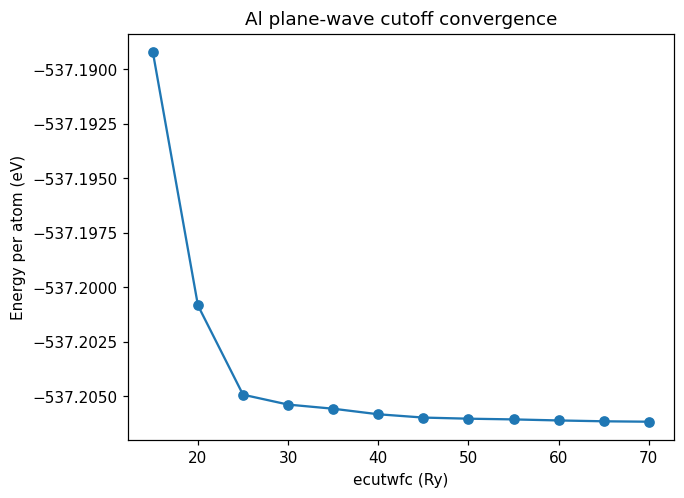

In [13]:
plt.plot(ecut_values, ecut_energies, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('Al plane-wave cutoff convergence')
plt.show()


In [14]:
# I am considering 10^(-3) [within 4 decimal places to the last one]
converged_ecutwfc = 50


In [18]:
#Kpoint Convergence
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14,16,18]
kpt_energies = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc
    d['system']['ecutrho'] = 8 * converged_ecutwfc
    a = bulk('Al', 'fcc', a=4.05)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp, input_data=d, kpts=(n, n, n))
    kpt_energies.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies[-1]:.5f} eV/atom')

2x2x2 k-mesh   E = -538.13430 eV/atom
3x3x3 k-mesh   E = -536.91294 eV/atom
4x4x4 k-mesh   E = -537.20602 eV/atom
5x5x5 k-mesh   E = -537.42465 eV/atom
6x6x6 k-mesh   E = -537.53591 eV/atom
8x8x8 k-mesh   E = -537.46445 eV/atom
10x10x10 k-mesh   E = -537.45614 eV/atom
12x12x12 k-mesh   E = -537.47725 eV/atom
14x14x14 k-mesh   E = -537.46377 eV/atom
16x16x16 k-mesh   E = -537.47373 eV/atom
18x18x18 k-mesh   E = -537.46851 eV/atom


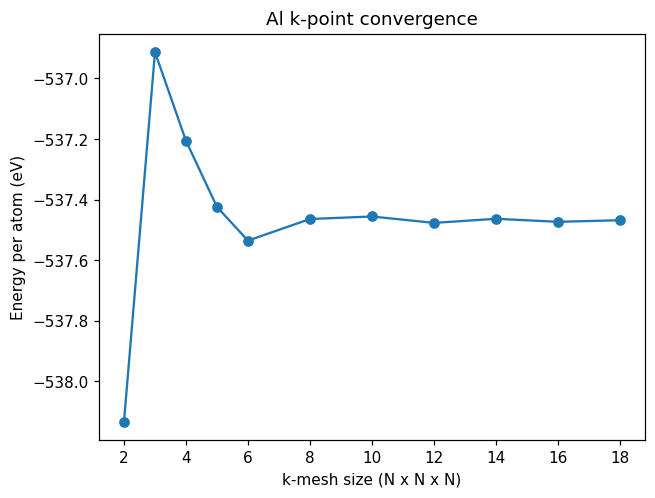

In [19]:
plt.plot(kgrids, kpt_energies, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('Al k-point convergence')
plt.show()


In [20]:
#Kpoints looks converged at 8, however for extra safety we could go for 10
converged_kpts = 10

In [21]:
#Now we can complete part 6 of class work properly as we have cutoffs for this pseudopotential
scale_factors = np.linspace(0.94, 1.06, 7)
volumes_sssp, energies_sssp = [], []

d = dict(input_data)
d['control'] = dict(input_data['control'])
d['control']['pseudo_dir'] = 'pseudo_sssp'
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc
d['system']['ecutrho'] = 8 * converged_ecutwfc

for s in scale_factors:
    a = bulk('Al', 'fcc', a=4.05 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp,
                       input_data=d, kpts=(converged_kpts, converged_kpts, converged_kpts))
    volumes_sssp.append(a.get_volume())
    energies_sssp.append(a.get_potential_energy())

eos_sssp = EquationOfState(volumes_sssp, energies_sssp, eos='birchmurnaghan')
v0_sssp, e0_sssp, B_sssp = eos_sssp.fit()
a0_sssp = v0_sssp ** (1 / 3)
a0 = 2.5465

print(f'GBRV: a0 = {a0:.4f} A')
print(f'SSSP: a0 = {a0_sssp:.4f} A')
print(f'Difference: {abs(a0 - a0_sssp):.4f} A  ({100*abs(a0 - a0_sssp)/a0:.2f}%)')

GBRV: a0 = 2.5465 A
SSSP: a0 = 2.5454 A
Difference: 0.0011 A  (0.04%)


we are getting the same difference even with the updated cutoffs

Bulk Modulus fit

In [23]:
scale_factors = np.linspace(0.94, 1.06, 7)
volumes, eos_energies = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc
d['system']['ecutrho'] = 8 * converged_ecutwfc

for s in scale_factors:
    a = bulk('Al', 'fcc', a=4.05 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp, input_data=d,
                       kpts=(converged_kpts, converged_kpts, converged_kpts))
    volumes.append(a.get_volume())
    eos_energies.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes[-1]:.2f} A^3   E = {eos_energies[-1]:.4f} eV')


a scale = 0.940   V = 13.79 A^3   E = -537.3107 eV
a scale = 0.960   V = 14.69 A^3   E = -537.3989 eV
a scale = 0.980   V = 15.63 A^3   E = -537.4446 eV
a scale = 1.000   V = 16.61 A^3   E = -537.4561 eV
a scale = 1.020   V = 17.62 A^3   E = -537.4403 eV
a scale = 1.040   V = 18.68 A^3   E = -537.4031 eV
a scale = 1.060   V = 19.78 A^3   E = -537.3492 eV


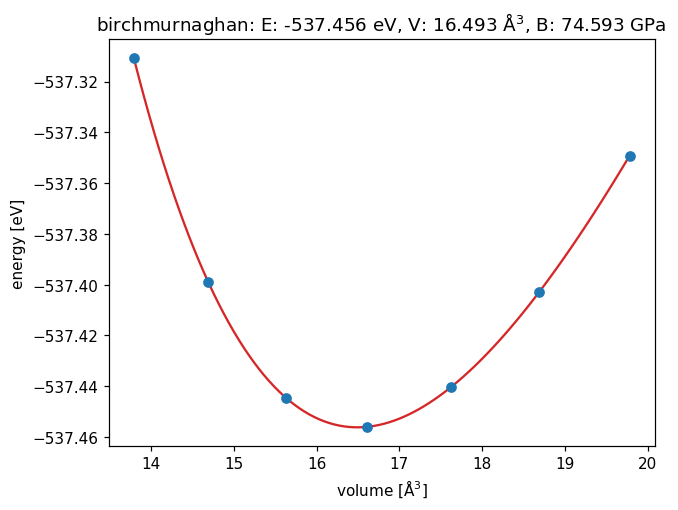

Equilibrium volume: 16.49 A^3, Lattice para: 2.55 A per primitive cell
Bulk modulus B0: 74.6 GPa


In [24]:
eos = EquationOfState(volumes, eos_energies, eos='birchmurnaghan')
v0, e0, B = eos.fit()
a0 = (v0 * 1) ** (1 / 3)
B_GPa = B / 6.242e-3   # eV/A^3 -> GPa

eos.plot()
plt.show()
print(f'Equilibrium volume: {v0:.2f} A^3, Lattice para: {a0:.2f} A per primitive cell')
print(f'Bulk modulus B0: {B_GPa:.1f} GPa')


we get 74.6 Gpa here compared to 73.7 Gpa with the other pseudopotential (lattice parameter is same upto two decimals)

Band Structure

In [25]:
a_eq = bulk('Al', 'fcc', a=a0)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])
scf_data['system']['ecutwfc'] = converged_ecutwfc
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc
a_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp, input_data=scf_data,
                      kpts=(converged_kpts, converged_kpts, converged_kpts))
a_eq.get_potential_energy()


-515.8382941344479

In [27]:
path = a_eq.cell.bandpath(npoints=250)
print(path)  # shows which special points ASE picked for this lattice, e.g. G, X, W, K, L

bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # <-- pw.x won't print eigenvalues for this many k-points otherwise

a_bands = bulk('Al', 'fcc', a=a0)
a_bands.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp,
                         input_data=bands_data, kpts=path)

results_bands = a_bands.get_properties(['eigenvalues'])


BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[250x3])


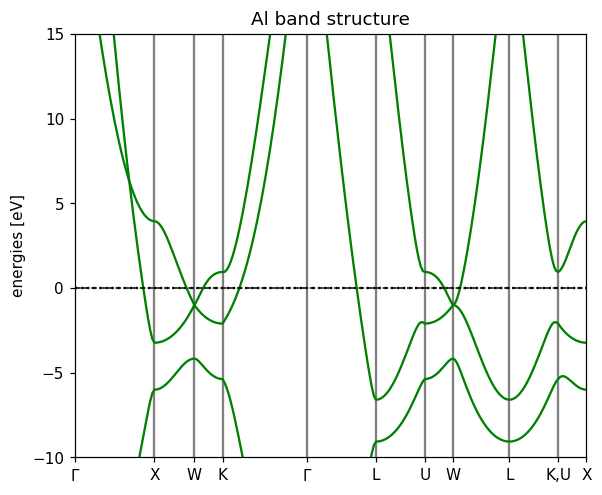

In [28]:
from ase.spectrum.band_structure import BandStructure
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))
bs.plot(ax=ax, emin=-10, emax=15)
ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi explicitly
ax.set_title('Al band structure')
plt.show()


Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
'al_pdos.pdos_atm#1(Al)_wfc#1(s)'   al_pdos.pdos_tot
'al_pdos.pdos_atm#1(Al)_wfc#2(p)'


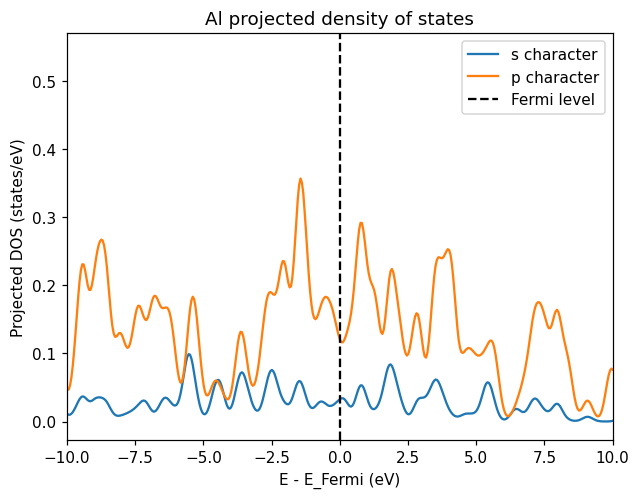

In [30]:
nscf_data = dict(scf_data)
nscf_data['control'] = dict(scf_data['control'])
nscf_data['control']['calculation'] = 'nscf'
nscf_data['system'] = dict(scf_data['system'])
nscf_data['system']['nosym'] = True

a_nscf = bulk('Al', 'fcc', a=a0)
a_nscf.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp,
                        input_data=nscf_data, kpts=(12, 12, 12))

from ase.calculators.calculator import PropertyNotImplementedError, PropertyNotPresent

try:
    a_nscf.get_properties(['eigenvalues'])
except (PropertyNotImplementedError, PropertyNotPresent):
    pass
projwfc_input = (
    "&PROJWFC\n"
    "  outdir='out',\n"
    "  prefix='pwscf',\n"
    "  filpdos='al_pdos',\n"
    "  degauss=0.02,\n"
    "  DeltaE=0.05,\n"
    "/\n"
)
with open('projwfc.in', 'w') as f:
    f.write(projwfc_input)
!projwfc.x -in projwfc.in > projwfc.out
!ls *pdos*
import glob

fermi = a_eq.calc.get_fermi_level()

def read_pdos_file(fname):
    """QE pdos files: col 0 = energy (eV), col 1 = ldos, cols 2.. = per-m pdos."""
    data = np.loadtxt(fname, comments='#')
    energy = data[:, 0] - fermi
    pdos = data[:, 2:].sum(axis=1)  # sum over m to get the orbital's total pdos
    return energy, pdos

s_files = glob.glob('al_pdos.pdos_atm*wfc*(s)')
p_files = glob.glob('al_pdos.pdos_atm*wfc*(p)')

energy = None
s_pdos = p_pdos = None
for fn in s_files:
    en, pd = read_pdos_file(fn)
    energy = en
    s_pdos = pd if s_pdos is None else s_pdos + pd
for fn in p_files:
    en, pd = read_pdos_file(fn)
    p_pdos = pd if p_pdos is None else p_pdos + pd

plt.plot(energy, s_pdos, label='s character')
if p_pdos is not None:
    plt.plot(energy, p_pdos, label='p character')
plt.axvline(0, color='k', linestyle='--', label='Fermi level')
plt.xlabel('E - E_Fermi (eV)')
plt.ylabel('Projected DOS (states/eV)')
plt.title('Al projected density of states')
plt.legend()
plt.xlim(-10, 10)
plt.show()


Our Band structure remains largely the same.
The projected density of states still follows the same trends as the before one, but apparers to be scaled down on the y axis.

###COPPER

In [31]:
#get pseudopotential
matches_1 = glob.glob('pseudo_sssp/**/Cu.*', recursive=True) + \
          glob.glob('pseudo_sssp/**/Cu_*', recursive=True)
if not matches:
    raise RuntimeError(
        "Could not find an CU pseudopotential in the extracted SSSP archive. "
        "Run !find pseudo_sssp -iname '*cu*' in a new cell to see what's "
        "actually in there, and adjust the glob pattern above to match."
    )

cu_sssp_path = matches_1[0]
cu_sssp_filename = os.path.basename(cu_sssp_path)
if cu_sssp_path != f'pseudo_sssp/{cu_sssp_filename}':
    shutil.move(cu_sssp_path, f'pseudo_sssp/{cu_sssp_filename}')
print('SSSP Cu pseudopotential:', cu_sssp_filename)

SSSP Cu pseudopotential: Cu.paw.z_11.ld1.psl.v1.0.0-low.upf


In [32]:
pseudopotentials_cu = {'Cu': cu_sssp_filename}

In [33]:
# Once again, for the confirmation
input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo_sssp', 'outdir': 'out',
                'tprnfor': True, 'tstress': True},  # print forces & stress too
    'system': {
        'ecutwfc': 25,       # a REASONABLE starting guess -- we will test this below
        'ecutrho': 200,
        'occupations': 'smearing', 'smearing': 'gaussian', 'degauss': 0.02,
    },
    'electrons': {'conv_thr': 1.0e-8},
}

atoms = bulk('Cu', 'fcc', a=3.61)
atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu, input_data=input_data,
                       kpts=(4, 4, 4))   # also just a starting guess
e0 = atoms.get_potential_energy()
print(f'Cu: E = {e0:.4f} eV  ({e0/len(atoms):.4f} eV/atom)')


Cu: E = -2897.5823 eV  (-2897.5823 eV/atom)


In [35]:
#energy cutoff convergence
ecut_values = [15,20,25,30, 35, 40, 45, 50,55,60,65,70]  # Ry
ecut_energies_cu = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('Cu', 'fcc', a=3.61)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu, input_data=d, kpts=(4, 4, 4))
    ecut_energies_cu.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies_cu[-1]:.5f} eV/atom')


ecutwfc =  15 Ry   E = -2855.78093 eV/atom
ecutwfc =  20 Ry   E = -2890.06143 eV/atom
ecutwfc =  25 Ry   E = -2897.58225 eV/atom
ecutwfc =  30 Ry   E = -2898.96454 eV/atom
ecutwfc =  35 Ry   E = -2899.11173 eV/atom
ecutwfc =  40 Ry   E = -2899.11857 eV/atom
ecutwfc =  45 Ry   E = -2899.13878 eV/atom
ecutwfc =  50 Ry   E = -2899.16042 eV/atom
ecutwfc =  55 Ry   E = -2899.17062 eV/atom
ecutwfc =  60 Ry   E = -2899.17291 eV/atom
ecutwfc =  65 Ry   E = -2899.17307 eV/atom
ecutwfc =  70 Ry   E = -2899.17392 eV/atom


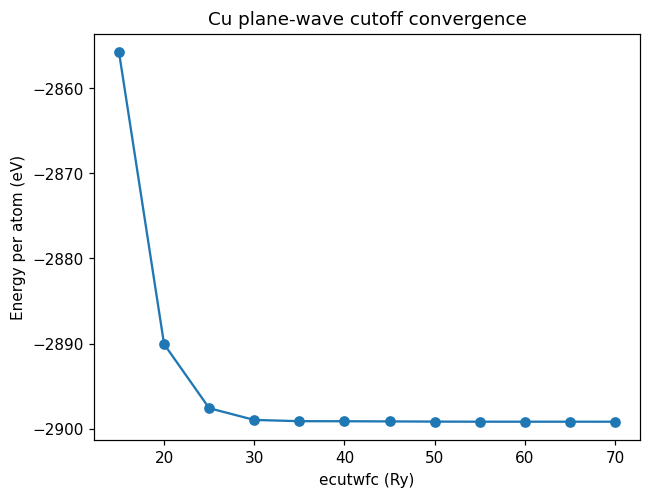

In [36]:
plt.plot(ecut_values, ecut_energies_cu, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('Cu plane-wave cutoff convergence')
plt.show()

In [37]:
converged_ecutwfc_cu = 30

In [38]:
#Kpoint Convergence
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14,16,18]
kpt_energies_cu = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc_cu
    d['system']['ecutrho'] = 8 * converged_ecutwfc_cu
    a = bulk('Cu', 'fcc', a=3.61)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu, input_data=d, kpts=(n, n, n))
    kpt_energies_cu.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies_cu[-1]:.5f} eV/atom')

2x2x2 k-mesh   E = -2897.15473 eV/atom
3x3x3 k-mesh   E = -2899.49713 eV/atom
4x4x4 k-mesh   E = -2898.96454 eV/atom
5x5x5 k-mesh   E = -2899.22265 eV/atom
6x6x6 k-mesh   E = -2899.06460 eV/atom
8x8x8 k-mesh   E = -2899.09173 eV/atom
10x10x10 k-mesh   E = -2899.10719 eV/atom
12x12x12 k-mesh   E = -2899.11654 eV/atom
14x14x14 k-mesh   E = -2899.11812 eV/atom
16x16x16 k-mesh   E = -2899.11952 eV/atom
18x18x18 k-mesh   E = -2899.11822 eV/atom


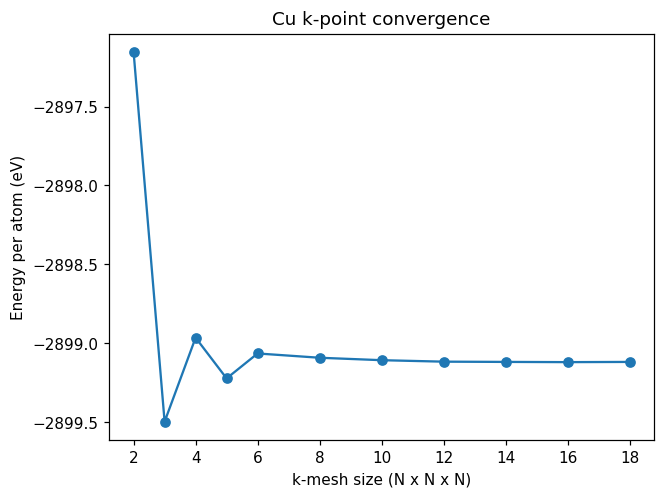

In [39]:
plt.plot(kgrids, kpt_energies_cu, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('Cu k-point convergence')
plt.show()


In [40]:
#As before, Kpoints looks converged at 8, however for extra safety we could go for 10
converged_kpts_cu = 10

FCC(a=3.61)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



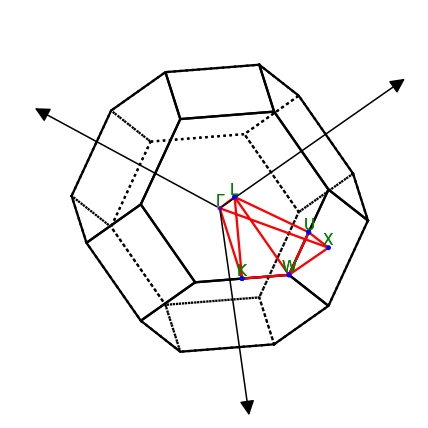

<Axes3D: >

In [41]:
#let us visualize brillouin zone of Cu

prim = bulk('Cu', 'fcc', a=3.61)
lat = prim.cell.get_bravais_lattice()
print(lat.description())
lat.plot_bz(show=True)

This is the same as Al as both are FCC

###Equation of state: lattice constant and bulk modulus

In [42]:
scale_factors = np.linspace(0.94, 1.06, 7)
volumes_cu, eos_energies_cu = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc_cu
d['system']['ecutrho'] = 8 * converged_ecutwfc_cu

for s in scale_factors:
    a = bulk('Cu', 'fcc', a=3.61 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu, input_data=d,
                       kpts=(converged_kpts_cu, converged_kpts_cu, converged_kpts_cu))
    volumes_cu.append(a.get_volume())
    eos_energies_cu.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes_cu[-1]:.2f} A^3   E = {eos_energies_cu[-1]:.4f} eV')


a scale = 0.940   V = 9.77 A^3   E = -2898.8456 eV
a scale = 0.960   V = 10.41 A^3   E = -2898.9977 eV
a scale = 0.980   V = 11.07 A^3   E = -2899.0817 eV
a scale = 1.000   V = 11.76 A^3   E = -2899.1072 eV
a scale = 1.020   V = 12.48 A^3   E = -2899.0955 eV
a scale = 1.040   V = 13.23 A^3   E = -2899.0549 eV
a scale = 1.060   V = 14.01 A^3   E = -2898.9915 eV


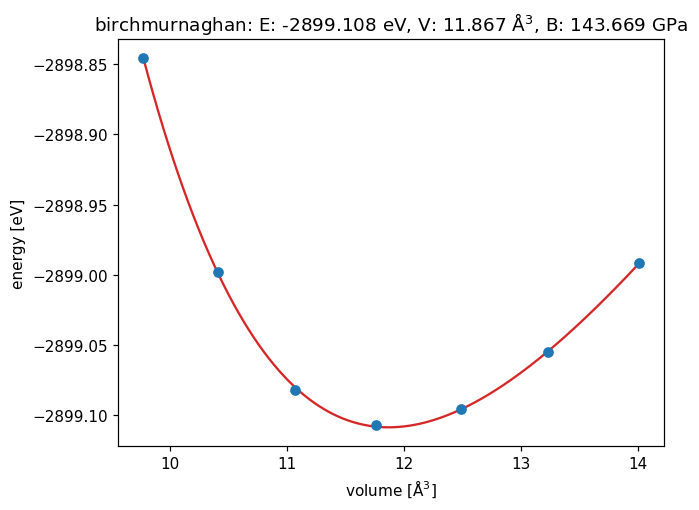

Equilibrium volume: 11.87 A^3, Lattice para: 2.28 A per primitive cell
Bulk modulus B0: 143.7 GPa


In [44]:
eos_cu = EquationOfState(volumes_cu, eos_energies_cu, eos='birchmurnaghan')
v0_cu, e0_cu, B_cu = eos_cu.fit()
a0_cu = (v0_cu * 1) ** (1 / 3)
B_GPa_cu = B_cu / 6.242e-3   # eV/A^3 -> GPa

eos_cu.plot()
plt.show()
print(f'Equilibrium volume: {v0_cu:.2f} A^3, Lattice para: {a0_cu:.2f} A per primitive cell')
print(f'Bulk modulus B0: {B_GPa_cu:.1f} GPa')

The bulk modulus agrees well with experimental value and is higher than the bulk molulus of Al

###Band structure and projected density of states

In [45]:
a_eq = bulk('Cu', 'fcc', a=a0_cu)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])
scf_data['system']['ecutwfc'] = converged_ecutwfc_cu
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc_cu
a_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu, input_data=scf_data,
                      kpts=(converged_kpts_cu, converged_kpts_cu, converged_kpts_cu))
a_eq.get_potential_energy()


-2854.811833015896

BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[250x3])


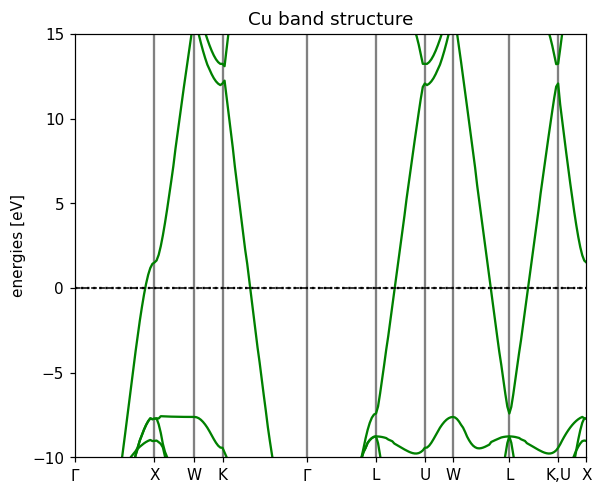

In [46]:
path = a_eq.cell.bandpath(npoints=250)
print(path)  # shows which special points ASE picked for this lattice, e.g. G, X, W, K, L

bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # <-- pw.x won't print eigenvalues for this many k-points otherwise

a_bands = bulk('Cu', 'fcc', a=a0_cu)
a_bands.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu,
                         input_data=bands_data, kpts=path)

results_bands = a_bands.get_properties(['eigenvalues'])
from ase.spectrum.band_structure import BandStructure
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))
bs.plot(ax=ax, emin=-10, emax=15)
ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi explicitly
ax.set_title('Cu band structure')
plt.show()


This bandstructure is completely different from Al , but we can see no bandgap, confirming that Cu is a conductor

'al_pdos.pdos_atm#1(Al)_wfc#1(s)'  'cu_pdos.pdos_atm#1(Cu)_wfc#2(p)'
'al_pdos.pdos_atm#1(Al)_wfc#2(p)'  'cu_pdos.pdos_atm#1(Cu)_wfc#3(d)'
 al_pdos.pdos_tot		    cu_pdos.pdos_tot
'cu_pdos.pdos_atm#1(Cu)_wfc#1(s)'


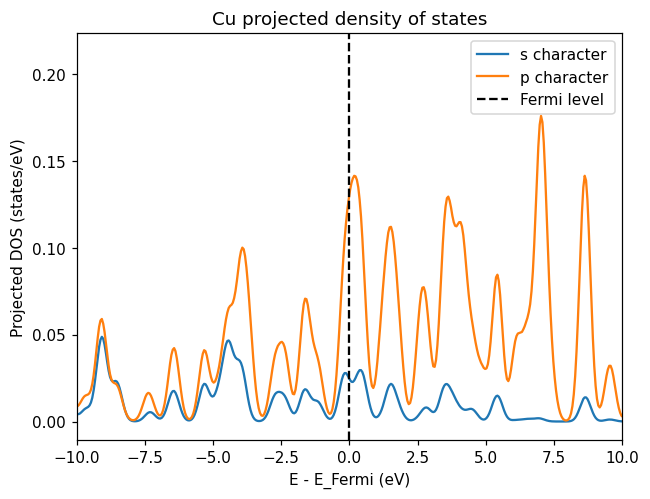

In [47]:
# Projected (orbital-resolved) density of states, via QE's projwfc.x.
# We run a denser non-self-consistent (nscf) calculation first, then
# project the wavefunctions onto atomic orbitals.
nscf_data = dict(scf_data)
nscf_data['control'] = dict(scf_data['control'])
nscf_data['control']['calculation'] = 'nscf'
nscf_data['system'] = dict(scf_data['system'])
nscf_data['system']['nosym'] = True

a_nscf = bulk('Cu', 'fcc', a=a0_cu)
a_nscf.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu,
                        input_data=nscf_data, kpts=(12, 12, 12))

from ase.calculators.calculator import PropertyNotImplementedError, PropertyNotPresent

try:
    a_nscf.get_properties(['eigenvalues'])
except (PropertyNotImplementedError, PropertyNotPresent):
    pass

projwfc_input = (
    "&PROJWFC\n"
    "  outdir='out',\n"
    "  prefix='pwscf',\n"
    "  filpdos='cu_pdos',\n"
    "  degauss=0.02,\n"
    "  DeltaE=0.05,\n"
    "/\n"
)
with open('projwfc.in', 'w') as f:
    f.write(projwfc_input)
!projwfc.x -in projwfc.in > projwfc.out
!ls *pdos*

import glob

fermi = a_eq.calc.get_fermi_level()

def read_pdos_file(fname):
    """QE pdos files: col 0 = energy (eV), col 1 = ldos, cols 2.. = per-m pdos."""
    data = np.loadtxt(fname, comments='#')
    energy = data[:, 0] - fermi
    pdos = data[:, 2:].sum(axis=1)  # sum over m to get the orbital's total pdos
    return energy, pdos

s_files = glob.glob('cu_pdos.pdos_atm*wfc*(s)')
p_files = glob.glob('cu_pdos.pdos_atm*wfc*(p)')

energy = None
s_pdos = p_pdos = None
for fn in s_files:
    en, pd = read_pdos_file(fn)
    energy = en
    s_pdos = pd if s_pdos is None else s_pdos + pd
for fn in p_files:
    en, pd = read_pdos_file(fn)
    p_pdos = pd if p_pdos is None else p_pdos + pd

plt.plot(energy, s_pdos, label='s character')
if p_pdos is not None:
    plt.plot(energy, p_pdos, label='p character')
plt.axvline(0, color='k', linestyle='--', label='Fermi level')
plt.xlabel('E - E_Fermi (eV)')
plt.ylabel('Projected DOS (states/eV)')
plt.title('Cu projected density of states')
plt.legend()
plt.xlim(-10, 10)
plt.show()





Again, this graph is completely different from Al grapgh, it is interesting to note that at lower energies, s and p almost have the same density of state

###Comparing energies of different phases

In [48]:
phase_structures = {
    'FCC':     ('fcc', 3.61),
    'BCC':     ('bcc', 2.86),
    'diamond': ('diamond', 4.54),
}   #choosen to give same volume per atom (approx)

phase_input_data = dict(input_data)
phase_input_data['system'] = dict(input_data['system'])
phase_input_data['system']['ecutwfc'] = converged_ecutwfc_cu
phase_input_data['system']['ecutrho'] = 8 * converged_ecutwfc_cu

phase_data = {}   # name -> (volumes_per_atom, energies_per_atom)

for name, (structure_type, a_guess) in phase_structures.items():
    scales = np.linspace(0.88, 1.12, 7)
    vols, energies = [], []
    for s in scales:
        a = bulk('Cu', structure_type, a=a_guess * s)
        a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_cu,
                           input_data=phase_input_data,
                           kpts=(converged_kpts_cu, converged_kpts_cu, converged_kpts_cu))
        vols.append(a.get_volume() / len(a))
        energies.append(a.get_potential_energy() / len(a))
    phase_data[name] = (vols, energies)
    print(f'{name}: done')


FCC: done
BCC: done
diamond: done


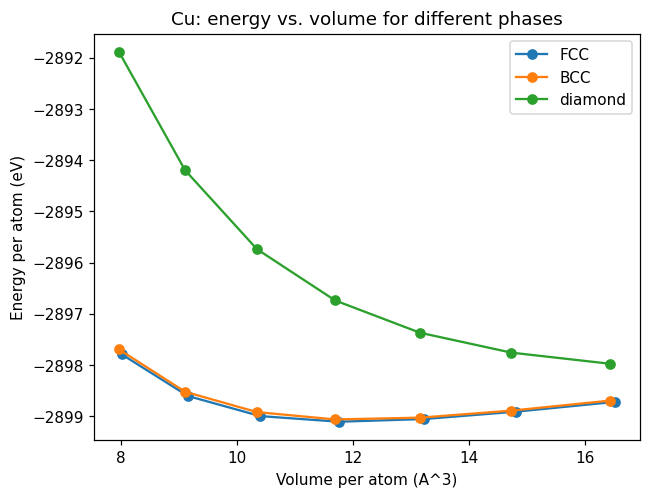

DFT predicts FCC has the lowest minimum energy per atom.


In [49]:
fig, ax = plt.subplots()
for name, (vols, energies) in phase_data.items():
    ax.plot(vols, energies, 'o-', label=name)
ax.set_xlabel('Volume per atom (A^3)')
ax.set_ylabel('Energy per atom (eV)')
ax.set_title('Cu: energy vs. volume for different phases')
ax.legend()
plt.show()

lowest = min(phase_data, key=lambda name: min(phase_data[name][1]))
print(f'DFT predicts {lowest} has the lowest minimum energy per atom.')


As expected, this is same as Al

In [50]:
def lower_hull(points):
    """Andrew's monotone-chain algorithm, keeping only the LOWER hull"""
    pts = sorted(set(points))
    lower = []
    for p in pts:
        while len(lower) >= 2:
            (x1, y1), (x2, y2) = lower[-2], lower[-1]
            cross = (x2 - x1) * (p[1] - y1) - (y2 - y1) * (p[0] - x1)
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append(p)
    return lower


def transition_pressure(phase_data, name_A, name_B):
    """Combine two phases' (V, E) points, take the lower convex hull, and
    look for the hull segment that connects a point from phase A directly
    to a point from phase B. That segment's slope is dE/dV = -P at the
    predicted transition. Returns the pressure in GPa, or None if the
    two phases don't actually cross within the volumes you sampled --
    which is a perfectly legitimate outcome, not an error, and tells you
    one phase simply dominates throughout this range."""
    tagged = ([(v, e, name_A) for v, e in zip(*phase_data[name_A])]
              + [(v, e, name_B) for v, e in zip(*phase_data[name_B])])
    tagged.sort()
    hull = lower_hull([(v, e) for v, e, _ in tagged])
    lookup = {(v, e): label for v, e, label in tagged}
    hull_labels = [lookup[(v, e)] for v, e in hull]

    for i in range(len(hull) - 1):
        if hull_labels[i] != hull_labels[i + 1]:
            (v1, e1), (v2, e2) = hull[i], hull[i + 1]
            if abs(v2 - v1) < 0.05:
                # Two near-identical volumes from different phases landing next
                # to each other on the hull is a numerical artifact, not a real
                # tangent -- skip it and keep looking for a genuine crossing.
                continue
            slope = (e2 - e1) / (v2 - v1)     # eV / A^3
            P_transition = -slope * 160.2      # eV/A^3 -> GPa
            print(f'Common-tangent segment found between {hull_labels[i]} '
                  f'and {hull_labels[i + 1]}')
            print(f'Estimated transition pressure: {P_transition:.1f} GPa')
            return P_transition
    print(f'No well-resolved {name_A}-{name_B} common-tangent segment found -- '
          f'one phase is likely lower in energy everywhere in this volume range.')
    return None


transition_pressure(phase_data, 'FCC', 'BCC')

No well-resolved FCC-BCC common-tangent segment found -- one phase is likely lower in energy everywhere in this volume range.


In [53]:
transition_pressure(phase_data, 'FCC', 'diamond')

No well-resolved FCC-diamond common-tangent segment found -- one phase is likely lower in energy everywhere in this volume range.


In [54]:
transition_pressure(phase_data, 'BCC', 'diamond')

No well-resolved BCC-diamond common-tangent segment found -- one phase is likely lower in energy everywhere in this volume range.


So, we can observe no proper phase transition in Cu, unlike Al where we did predict an FCC to BCC phase transition

## Discuss/Explain

**Question: DFT calculations almost always use the primitive cell for a bulk crystal, even though the conventional cell describes exactly the same infinite solid. Given that computational cost grows steeply with the number of atoms in the cell, why is the primitive cell the natural choice?**

Primitive cell, by definition, has the least number of atoms and hence , computational cost is least for it, and is hence preferred

**Question: For this perfect, unrelaxed Al crystal, do you expect the forces on each atom to be exactly zero, close to zero, or something else entirely? What would a nonzero force on every atom be telling you about the structure you gave QE?**

I would expect it to be exactly zero because of the symmetry of the crystal, each Al is surrounded by its neighbours in symmetric positions, so the forces cancel out and the net force turns out to be zero

**Question: Notice the number of k-points printed in the output file. Do they match with the number of k-points mentioned in the input? What is wk printed along with the k-points?**



No they do not. we gave 4x4x4 but it used 5. This is because KPOINT generation is done by certain algorithms (like MonkHorst Pack) which uses our KPOINT as an input to its alogorithms and generates the KPOINT mesh.
The wk denote the weight of the kpoint so that calculations can be done in the irreducible brilloiun zone and multiplied by the weight to get answer to the entire brillouin zone. These weights correspond to the symmetry of each KPOINT

**Question: How does the computational time scale with the k-point grid?**

computational time increases with increasing KPOINTS

**Question: Look up the experimental lattice constant and bulk modulus of Al. Do they match. What are the most likely causes of mismatch with the experimental values?**

Experimental values of bulk modulus of Al is around 76 Gpa, and our value (73.7) is a really good match for it. the errors could be from usuage of pseudopotentials, numerical errors that get carried over in each iteration, lesser number of kpoints are plane waves used etc... Or they could be from the fundamental approximations made in DFT itself, like exchange correlation.

**Question: Which orbital character (s or p) dominates near the Fermi level for Al? Does that match with your expectation?**

P dominates near Fermi Level for Al, this matches my expectation as the final electroons of Al do occupy the P orbital

**Question: How would a projected DOS for an insulator look like near E_Fermi?**

DOS would sharply fall to zero after the fermi level, indicating that there are no elecrons in the conduction band

**Question: How does the GBRV-vs-SSSP difference in a0 compare to DFT match with the experimental lattice constant? Is pseudopotential choice a small correction on top of everything else DFT assumes, or comparable in size to the other approximations you've already been making?**

Lattice Parameter of Al (primitive) is around 2.8 Angstroms, we got 2.54 using both the pseudoptentials , which is a good estimate. I feel that pseudopotential is small enough compared to other approximations as most of the propeties of the material that we deal with of a material is a function of its valence electrons and thus making approximations in the core should not really affect anything by a huge margin

**Question: Try this for a different pair of phases (transition_pressure(phase_data, 'FCC', 'diamond'), for instance)**

In [56]:
phase_structures = {
    'FCC':     ('fcc', 4.05),
    'BCC':     ('bcc', 3.2),
    'diamond': ('diamond', 6),
}   #choosen to give same volume per atom (approx)

phase_input_data = dict(input_data)
phase_input_data['system'] = dict(input_data['system'])
phase_input_data['system']['ecutwfc'] = converged_ecutwfc
phase_input_data['system']['ecutrho'] = 8 * converged_ecutwfc

phase_data = {}   # name -> (volumes_per_atom, energies_per_atom)

for name, (structure_type, a_guess) in phase_structures.items():
    scales = np.linspace(0.88, 1.12, 7)
    vols, energies = [], []
    for s in scales:
        a = bulk('Al', structure_type, a=a_guess * s)
        a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp,
                           input_data=phase_input_data,
                           kpts=(converged_kpts, converged_kpts, converged_kpts))
        vols.append(a.get_volume() / len(a))
        energies.append(a.get_potential_energy() / len(a))
    phase_data[name] = (vols, energies)
    print(f'{name}: done')


FCC: done
BCC: done
diamond: done


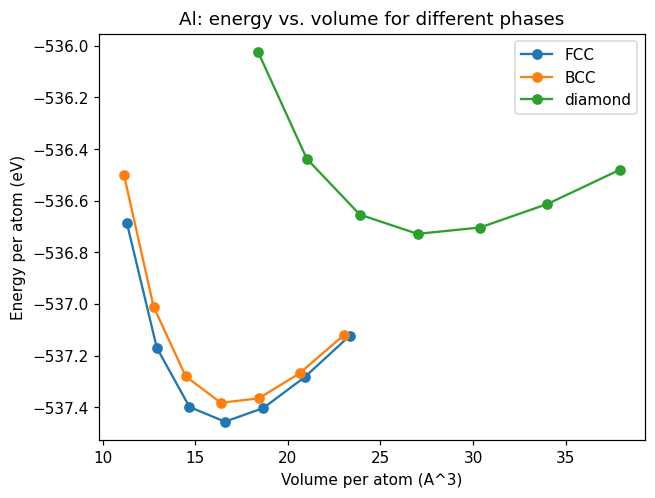

DFT predicts FCC has the lowest minimum energy per atom.


In [57]:
fig, ax = plt.subplots()
for name, (vols, energies) in phase_data.items():
    ax.plot(vols, energies, 'o-', label=name)
ax.set_xlabel('Volume per atom (A^3)')
ax.set_ylabel('Energy per atom (eV)')
ax.set_title('Al: energy vs. volume for different phases')
ax.legend()
plt.show()

lowest = min(phase_data, key=lambda name: min(phase_data[name][1]))
print(f'DFT predicts {lowest} has the lowest minimum energy per atom.')

In [59]:
def lower_hull(points):
    """Andrew's monotone-chain algorithm, keeping only the LOWER hull"""
    pts = sorted(set(points))
    lower = []
    for p in pts:
        while len(lower) >= 2:
            (x1, y1), (x2, y2) = lower[-2], lower[-1]
            cross = (x2 - x1) * (p[1] - y1) - (y2 - y1) * (p[0] - x1)
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append(p)
    return lower


def transition_pressure(phase_data, name_A, name_B):
    """Combine two phases' (V, E) points, take the lower convex hull, and
    look for the hull segment that connects a point from phase A directly
    to a point from phase B. That segment's slope is dE/dV = -P at the
    predicted transition. Returns the pressure in GPa, or None if the
    two phases don't actually cross within the volumes you sampled --
    which is a perfectly legitimate outcome, not an error, and tells you
    one phase simply dominates throughout this range."""
    tagged = ([(v, e, name_A) for v, e in zip(*phase_data[name_A])]
              + [(v, e, name_B) for v, e in zip(*phase_data[name_B])])
    tagged.sort()
    hull = lower_hull([(v, e) for v, e, _ in tagged])
    lookup = {(v, e): label for v, e, label in tagged}
    hull_labels = [lookup[(v, e)] for v, e in hull]

    for i in range(len(hull) - 1):
        if hull_labels[i] != hull_labels[i + 1]:
            (v1, e1), (v2, e2) = hull[i], hull[i + 1]
            if abs(v2 - v1) < 0.05:
                # Two near-identical volumes from different phases landing next
                # to each other on the hull is a numerical artifact, not a real
                # tangent -- skip it and keep looking for a genuine crossing.
                continue
            slope = (e2 - e1) / (v2 - v1)     # eV / A^3
            P_transition = -slope * 160.2      # eV/A^3 -> GPa
            print(f'Common-tangent segment found between {hull_labels[i]} '
                  f'and {hull_labels[i + 1]}')
            print(f'Estimated transition pressure: {P_transition:.1f} GPa')
            return P_transition
    print(f'No well-resolved {name_A}-{name_B} common-tangent segment found -- '
          f'one phase is likely lower in energy everywhere in this volume range.')
    return None


transition_pressure(phase_data, 'diamond', 'FCC')


Common-tangent segment found between FCC and diamond
Estimated transition pressure: -7.7 GPa


np.float64(-7.682301290756596)

In [60]:
transition_pressure(phase_data, 'diamond', 'BCC')


Common-tangent segment found between BCC and diamond
Estimated transition pressure: -7.3 GPa


np.float64(-7.304368559846967)